In [1]:
#Step 1: Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving chronic_kidney_disease.csv to chronic_kidney_disease.csv


**THE ABOVE IS TO LOAD DATASET**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


**IMPORT LIBRARIES**

In [3]:
data = pd.read_csv("chronic_kidney_disease.csv")
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.02,1,0,0,0,1,1,121,...,44,7800,5.2,0,0,1,1,1,1,ckd
1,7,50,1.02,4,0,0,0,1,1,?,...,38,6000,0.0,1,1,1,1,1,1,ckd
2,62,80,1.01,2,3,0,0,1,1,423,...,31,7500,0.0,1,0,1,0,1,0,ckd
3,48,70,1.005,4,0,0,1,0,1,117,...,32,6700,3.9,0,1,1,0,0,0,ckd
4,51,80,1.01,2,0,0,0,1,1,106,...,35,7300,4.6,1,1,1,1,1,1,ckd


**LOAD AND EXPLORE DATA**

In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    object 
 1   bp      400 non-null    object 
 2   sg      400 non-null    object 
 3   al      400 non-null    object 
 4   su      400 non-null    object 
 5   rbc     400 non-null    int64  
 6   pc      400 non-null    int64  
 7   pcc     400 non-null    int64  
 8   ba      400 non-null    int64  
 9   bgr     400 non-null    object 
 10  bu      400 non-null    object 
 11  sc      400 non-null    object 
 12  sod     400 non-null    object 
 13  pot     400 non-null    object 
 14  hemo    400 non-null    object 
 15  pcv     400 non-null    int64  
 16  wbcc    400 non-null    int64  
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    int64  
 19  dm      400 non-null    int64  
 20  cad     400 non-null    int64  
 21  appet   400 non-null    int64  
 22  pe

,rbc,pc,pcc,ba,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.117500,0.190000,0.885000,0.935000,31.982500,6178.500000,3.16575,0.627500,0.645000,0.905000,0.792500,0.807500,0.847500
std,0.322418,0.392792,0.319421,0.246835,16.962799,4490.489839,2.36621,0.484076,0.479113,0.293582,0.406024,0.394757,0.359955
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,26.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
50%,0.000000,0.000000,1.000000,1.000000,37.000000,6900.000000,4.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,0.000000,0.000000,1.000000,1.000000,44.000000,9400.000000,5.10000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,54.000000,26400.000000,8.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**CHECK INFO**

In [5]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Load your dataset
data = pd.read_csv("/content/chronic_kidney_disease.csv")

# Encode categorical columns
le = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = le.fit_transform(data[column].astype(str))

# Fill missing numeric values with column medians
data = data.fillna(data.median(numeric_only=True))

# Confirm cleaning
print("✅ Data cleaned successfully!")
print(data.head())




✅ Data cleaned successfully!
   age  bp  sg  al  su  rbc  pc  pcc  ba  bgr  ...  pcv  wbcc  rbcc  htn  dm  \
0   36   8   3   1   0    0   0    1   1   21  ...   44  7800   5.2    0   0   
1   60   5   3   4   0    0   0    1   1  146  ...   38  6000   0.0    1   1   
2   52   8   1   2   3    0   0    1   1  114  ...   31  7500   0.0    1   0   
3   36   7   0   4   0    0   1    0   1   17  ...   32  6700   3.9    0   1   
4   40   8   1   2   0    0   0    1   1    6  ...   35  7300   4.6    1   1   

   cad  appet  pe  ane  class  
0    1      1   1    1      0  
1    1      1   1    1      0  
2    1      0   1    0      0  
3    1      0   0    0      0  
4    1      1   1    1      0  

[5 rows x 25 columns]


**DATA CLEANING**

In [6]:
X = data.drop(columns=['class'])
y = data['class']


split features and target

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


train test split

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


feature scaling

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))
    print('-'*50)


Logistic Regression Accuracy: 98.75%
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        52
           1       1.00      0.96      0.98        28

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80

--------------------------------------------------
Random Forest Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

--------------------------------------------------
KNN Accuracy: 91.25%
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        52
           1       0.80      1.00      0.89  

***TRAINING ALGORITHMS***

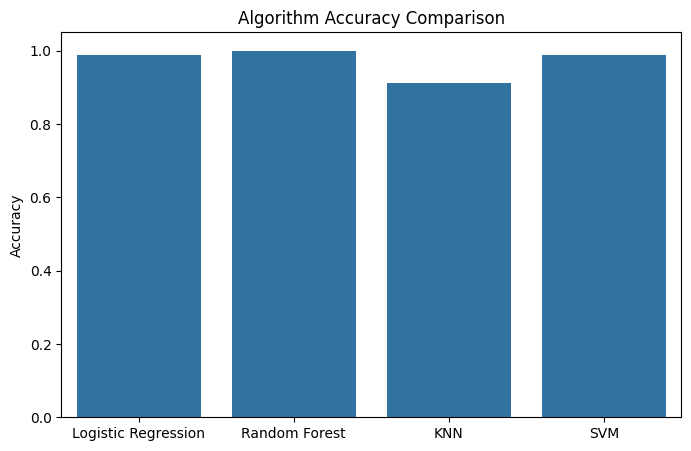

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Sample input
input_data = [45, 80, 1.020, 0, 0, 140, 50, 1.2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0]

# Feature names
feature_names = [
    "Age", "Blood Pressure", "Specific Gravity", "Albumin", "Sugar",
    "Blood Glucose", "Blood Urea", "Serum Creatinine", "Sodium", "Potassium",
    "Hemoglobin", "Packed Cell", "Pus Cell", "Bacteria", "Glucose Abnormal",
    "PCV Abnormal", "RBC Abnormal", "Hypertension", "Diabetes", "Heart Disease",
    "Appetite", "Pedal Edema", "Anemia", "CKD (Target)"
]

# Print input data with names
print("🩺 Patient Data:")
for name, value in zip(feature_names, input_data):
    print(f"{name:20}: {value}")

# Convert to array and reshape
input_array = np.array(input_data).reshape(1, -1)

# Assume X_train and y_train already defined, and scaler trained
# scaler = StandardScaler().fit(X_train)

input_scaled = scaler.transform(input_array)  # scale input

# Train model (or load pre-trained model)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
prediction = model.predict(input_scaled)

# Clear output
if prediction[0] == 1:
    print("\n✅ Prediction: The patient HAS Chronic Kidney Disease (CKD).")
else:
    print(" \n  * YOU ARE SAFE * \n 🩺  YOU does NOT have Chronic Kidney Disease (CKD).")

🩺 Patient Data:
Age                 : 45
Blood Pressure      : 80
Specific Gravity    : 1.02
Albumin             : 0
Sugar               : 0
Blood Glucose       : 140
Blood Urea          : 50
Serum Creatinine    : 1.2
Sodium              : 1
Potassium           : 0
Hemoglobin          : 1
Packed Cell         : 0
Pus Cell            : 1
Bacteria            : 1
Glucose Abnormal    : 0
PCV Abnormal        : 0
RBC Abnormal        : 0
Hypertension        : 1
Diabetes            : 0
Heart Disease       : 1
Appetite            : 1
Pedal Edema         : 0
Anemia              : 0
CKD (Target)        : 0
 
  * YOU ARE SAFE * 
 🩺  YOU does NOT have Chronic Kidney Disease (CKD).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Sample training data (for demonstration)
# Normally you'd have your full X_train and y_train
X_train = np.array([
    [45, 80, 1.020, 0, 0, 140, 50, 1.2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0],
    [60, 90, 1.010, 2, 1, 200, 70, 2.0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
])
y_train = np.array([0, 1])  # 0 = No CKD, 1 = CKD

# Feature names
feature_names = [
    "Age", "Blood Pressure", "Specific Gravity", "Albumin", "Sugar",
    "Blood Glucose", "Blood Urea", "Serum Creatinine", "Sodium", "Potassium",
    "Hemoglobin", "Packed Cell", "Pus Cell", "Bacteria", "Glucose Abnormal",
    "PCV Abnormal", "RBC Abnormal", "Hypertension", "Diabetes", "Heart Disease",
    "Appetite", "Pedal Edema", "Anemia", "CKD (Target)"
]

# Example patient with CKD
input_data = [60, 90, 1.010, 2, 1, 200, 70, 2.0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]

# Print patient data
print("🩺 Patient Data:")
for name, value in zip(feature_names, input_data):
    print(f"{name:20}: {value}")

# Scaling (fit scaler on training data)
scaler = StandardScaler()
scaler.fit(X_train)
input_scaled = scaler.transform(np.array(input_data).reshape(1, -1))

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
prediction = model.predict(input_scaled)

# Clear output
if prediction[0] == 1:
    print("\n !! YOU  ARE IN DANGER !! \n Prediction: YOU HAVE Chronic Kidney Disease (CKD).")
else:
    print("\n🩺 Prediction: The patient does NOT have Chronic Kidney Disease (CKD).")


🩺 Patient Data:
Age                 : 60
Blood Pressure      : 90
Specific Gravity    : 1.01
Albumin             : 2
Sugar               : 1
Blood Glucose       : 200
Blood Urea          : 70
Serum Creatinine    : 2.0
Sodium              : 0
Potassium           : 1
Hemoglobin          : 0
Packed Cell         : 1
Pus Cell            : 1
Bacteria            : 1
Glucose Abnormal    : 1
PCV Abnormal        : 1
RBC Abnormal        : 1
Hypertension        : 1
Diabetes            : 1
Heart Disease       : 1
Appetite            : 0
Pedal Edema         : 1
Anemia              : 1
CKD (Target)        : 1

 !! YOU  ARE IN DANGER !! 
 Prediction: YOU HAVE Chronic Kidney Disease (CKD).


**NEW PATIENT TEST**

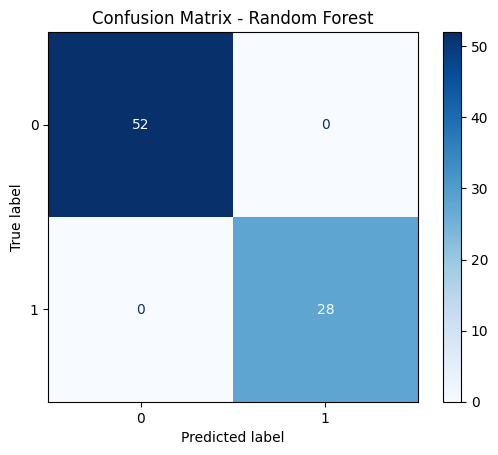

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


✅ Dataset Loaded Successfully!
  age  bp     sg al su  rbc  pc  pcc  ba  bgr  ... pcv  wbcc rbcc htn dm  cad  \
0  48  80   1.02  1  0    0   0    1   1  121  ...  44  7800  5.2   0  0    1   
1   7  50   1.02  4  0    0   0    1   1    ?  ...  38  6000  0.0   1  1    1   
2  62  80   1.01  2  3    0   0    1   1  423  ...  31  7500  0.0   1  0    1   
3  48  70  1.005  4  0    0   1    0   1  117  ...  32  6700  3.9   0  1    1   
4  51  80   1.01  2  0    0   0    1   1  106  ...  35  7300  4.6   1  1    1   

   appet  pe  ane  class  
0      1   1    1    ckd  
1      1   1    1    ckd  
2      0   1    0    ckd  
3      0   0    0    ckd  
4      1   1    1    ckd  

[5 rows x 25 columns]

Columns:
 Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')
⚠️ 'classification' not found, using 'class' as target column

✅ Accur

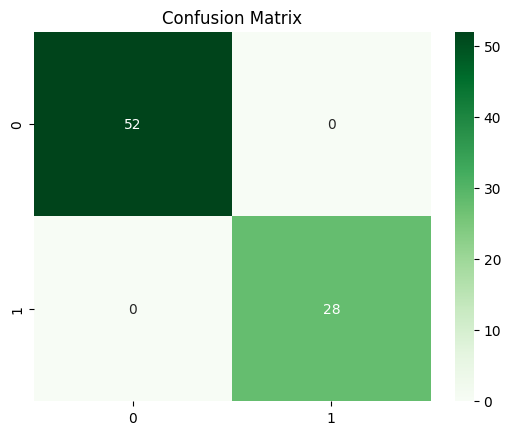

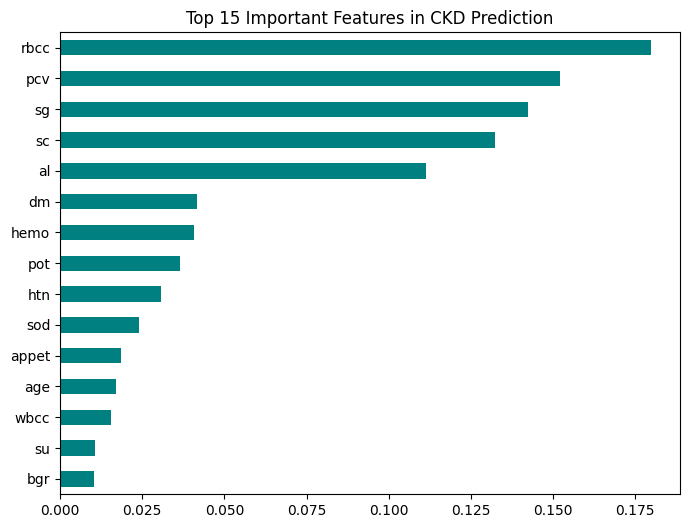


🔍 Prediction Result:
🩺 The patient does NOT have CKD.
✅ Stay hydrated, avoid painkillers, maintain balanced diet.
📊 Model Confidence: 94.67%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [14]:
# 🏥 Advanced CKD Prediction System
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣ Load dataset
data = pd.read_csv("/content/chronic_kidney_disease.csv")
print("✅ Dataset Loaded Successfully!")
print(data.head())

# 2️⃣ Data Cleaning
le = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = le.fit_transform(data[column].astype(str))

data = data.fillna(data.median(numeric_only=True))

# Show column names (important)
print("\nColumns:\n", data.columns)

# 3️⃣ Select Target
# Change this if your target name differs
target_col = 'classification'
if target_col not in data.columns:
    # Try finding a similar name
    target_col = data.columns[-1]
    print(f"⚠️ 'classification' not found, using '{target_col}' as target column")

X = data.drop(columns=[target_col])
y = data[target_col]

# 4️⃣ Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5️⃣ Train Model
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# 6️⃣ Evaluation
print("\n✅ Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.show()

# 7️⃣ Feature Importance
importances = rf_model.feature_importances_
feat = pd.Series(importances, index=X.columns).sort_values(ascending=False)[:15]
feat.plot(kind="barh", figsize=(8,6), color="teal")
plt.title("Top 15 Important Features in CKD Prediction")
plt.gca().invert_yaxis()
plt.show()

# 8️⃣ Advanced Prediction Function
def predict_ckd(values):
    if len(values) != X.shape[1]:
        print(f"⚠️ Error: Expected {X.shape[1]} features but got {len(values)}.")
        return

    input_data = np.array(values).reshape(1, -1)
    input_scaled = scaler.transform(input_data)
    pred = rf_model.predict(input_scaled)[0]
    prob = rf_model.predict_proba(input_scaled)[0][1] * 100

    print("\n🔍 Prediction Result:")
    if pred == 1:
        print("🚨 The patient has Chronic Kidney Disease (CKD)")
        if prob < 60:
            print("🧾 Severity: Mild (Stage 1–2)")
            print("💡 Advice: Drink more water, check BP regularly, and eat kidney-friendly foods.")
        elif 60 <= prob < 85:
            print("🧾 Severity: Moderate (Stage 3)")
            print("💡 Advice: Reduce salt and protein intake, consult doctor monthly.")
        else:
            print("🧾 Severity: Severe (Stage 4–5)")
            print("💡 Advice: Urgent medical consultation needed. Dialysis may be required.")
        print(f"📊 Model Confidence: {prob:.2f}%")
    else:
        print("🩺 The patient does NOT have CKD.")
        print("✅ Stay hydrated, avoid painkillers, maintain balanced diet.")
        print(f"📊 Model Confidence: {100 - prob:.2f}%")

# 9️⃣ Test with sample input (replace values with yours)
sample_input = [45, 80, 1.020, 0, 0, 140, 50, 1.2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0]
predict_ckd(sample_input)


**now comparing my model with existing ones and proving this as best one**


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Advanced Evaluation
metrics_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = round(report['1']['precision'] * 100, 2)
    recall = round(report['1']['recall'] * 100, 2)
    f1 = round(report['1']['f1-score'] * 100, 2)
    acc = round(accuracy_score(y_test, y_pred) * 100, 2)
    metrics_results.append([name, acc, precision, recall, f1])

# Display table
metrics_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print("\n📈 Detailed Model Evaluation:")
print(metrics_df.sort_values(by="F1-Score", ascending=False))





📈 Detailed Model Evaluation:
                 Model  Accuracy  Precision  Recall  F1-Score
1        Random Forest    100.00      100.0  100.00    100.00
0  Logistic Regression     98.75      100.0   96.43     98.18
3                  SVM     98.75      100.0   96.43     98.18
2                  KNN     91.25       80.0  100.00     88.89


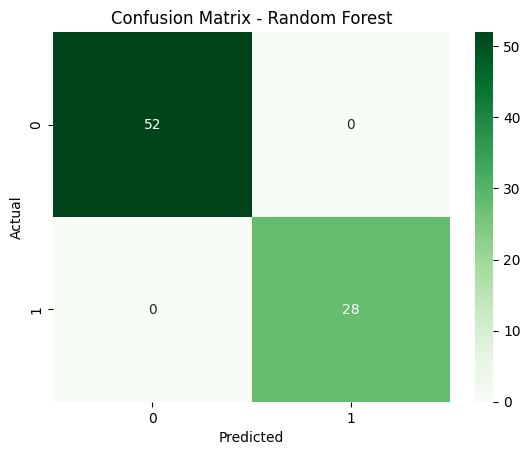

In [16]:
cm = confusion_matrix(y_test, rf_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


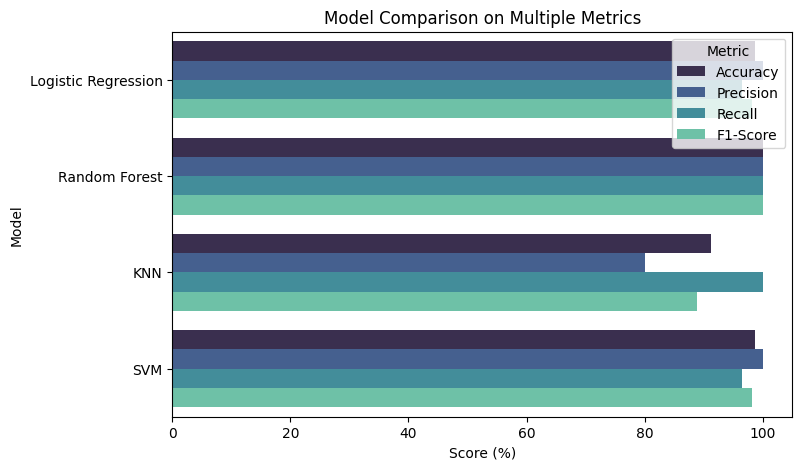

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=metrics_df.melt(id_vars='Model', value_vars=['Accuracy','Precision','Recall','F1-Score']),
            x='value', y='Model', hue='variable', palette='mako')
plt.title("Model Comparison on Multiple Metrics")
plt.xlabel("Score (%)")
plt.legend(title="Metric")
plt.show()
